In [228]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Pretraining

In [229]:
# All the signals we will use in the model

xml_signals = ["glucose_level", "basis_heart_rate", "basis_gsr",
           "basis_skin_temperature", "basis_air_temperature"]
signals = ["glucose_level", "basis_heart_rate", "basis_gsr",
           "basis_skin_temperature", "basis_air_temperature",
           "running_IOB", "self_reported_carbs", "sin_t", "cos_t"]
signals_for_loss = ["glucose_level", "basis_heart_rate", "basis_gsr",
           "basis_skin_temperature", "basis_air_temperature"]

start_time = pd.Timestamp('2020-06-01 10:00:00')


In [230]:
def get_bolus_df(subject_num, split):

    bolus_df = pd.read_xml(f'bolus_data/{subject_num}-ws-{split}.xml', xpath="./bolus/event")
    bolus_df["date_time"] = pd.to_datetime(bolus_df['ts_begin'], format='%d-%m-%Y %H:%M:%S')
    bolus_df['running_minutes'] = (bolus_df['date_time'] - start_time).dt.total_seconds() / 60
    bolus_df = bolus_df.sort_values('running_minutes').reset_index(drop=True)  # fixes bug #5 too
    return bolus_df

In [231]:
def load_data(subject_num, split):

    bolus_df = get_bolus_df(subject_num, split)

    # load each signal separately
    signal_dfs = {}
    for signal in xml_signals:
        sig_df = pd.read_xml(f'bolus_data/{subject_num}-ws-{split}.xml', xpath=f"./{signal}/event")
        sig_df['date_time'] = pd.to_datetime(sig_df['ts'], format='%d-%m-%Y %H:%M:%S')
        sig_df = sig_df[['date_time', 'value']].rename(columns={'value': signal})
        signal_dfs[signal] = sig_df.sort_values('date_time').reset_index(drop=True)

    # align all signals into one dataset using date_time
    df = signal_dfs['glucose_level']
    for signal in xml_signals[1:]:
        df = pd.merge_asof(
            df, signal_dfs[signal],
            on='date_time',
            direction='backward',
            tolerance=pd.Timedelta('2.5min')
        )

    df["minutes"] = (df["date_time"] - start_time).dt.total_seconds() / 60
    df["running_IOB"] = 0.0
    df["self_reported_carbs"] = 0.0
    overlap_start = max(df.loc[df[col].notna(), 'date_time'].min()
                     for col in ['basis_heart_rate', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature'])
    overlap_end = min(df.loc[df[col].notna(), 'date_time'].max()
                   for col in ['basis_heart_rate', 'basis_gsr', 'basis_skin_temperature', 'basis_air_temperature'])
    df = df[(df['date_time'] >= overlap_start) & (df['date_time'] <= overlap_end)].reset_index(drop=True)
    return df, bolus_df

In [232]:
def iob_falling(t, peak, dia):
    return 1 - peak/dia - (2 / (dia * (dia - peak))) * ((dia*t - t**2/2) - (dia*peak - peak**2/2))

def generate_cyclical_time_encoding(inp_df):
  inp_df["slot"] = (inp_df["date_time"].dt.hour * 60 + inp_df["date_time"].dt.minute) // 5
  inp_df["sin_t"] = np.sin(2 * np.pi * inp_df["slot"] / 288)
  inp_df["cos_t"] = np.cos(2 * np.pi * inp_df["slot"] / 288)
  return inp_df

#calculate insulin on board as extra feature
def calc_IOB(inp_df, bolus, peak, dia):
  for row in inp_df.itertuples():
    curr_iob = 0

    for row_bolus in bolus.itertuples():
      t = row.minutes - row_bolus.running_minutes
      if t >= 0 and t < 5:
        inp_df.at[row.Index, "self_reported_carbs"] = row_bolus.bwz_carb_input
      if t < 0:
        break
      if t == 0:
        curr_iob += row_bolus.dose
      elif t <= peak:
        curr_iob += row_bolus.dose * (1 - ((t ** 2) / (dia * peak)))
      elif t <= dia:
        curr_iob += row_bolus.dose * iob_falling(t, peak, dia)
    inp_df.at[row.Index, "running_IOB"] = curr_iob
  return inp_df

In [233]:
#zscore for all cols, and log transform for gsr and carbs only

def preprocess_data(df, signals, means=None, stds=None):
  df["basis_gsr"] = np.log1p(df["basis_gsr"])
  df["self_reported_carbs"] = np.log1p(df["self_reported_carbs"])
  for col in signals[:-2]:
    df[col] = (df[col] - means[col]) / stds[col]
  df = df.fillna(0.0)
  return df, df[signals_for_loss]

In [234]:
def get_data(subject_num, split):

  df, bolus_df = load_data(subject_num, split)
  df = calc_IOB(df, bolus_df, 75, 300)

  df_p = generate_cyclical_time_encoding(df)

  mask = (~df_p[signals_for_loss].isna()).to_numpy().astype(np.float32)
  return df_p, bolus_df[["dose", "date_time"]], mask

In [235]:
subject_ids = [563, 559, 570, 575, 588]
subject_ids_test = [591]
training_concat = np.array([])

subject_dfs = {}

#for use in fine_tuning step
bolus_dfs = {}

training_d = {}
testing_d = {}


In [236]:
#loads data, no preprocessing yet because we need mean and stds for z-score

for subject_num in subject_ids + subject_ids_test:
  print(f"parsing {subject_num}")
  x, bolus_df, mask = get_data(subject_num, "training")
  subject_dfs[subject_num] = (x, mask)
  bolus_dfs[subject_num] = bolus_df
  if subject_num in subject_ids:
    if training_concat.shape[0] == 0:
      training_concat = subject_dfs[subject_num][0][signals]
    else:
      training_concat = np.concatenate((training_concat, subject_dfs[subject_num][0][signals]))

parsing 563
parsing 559
parsing 570
parsing 575
parsing 588
parsing 591


In [237]:
#calc z score from training subjects

means = {}
stds = {}

for index, signal in enumerate(signals[:-2]):
  means[signal] = np.nanmean(training_concat[:, index])
  stds[signal] = np.nanstd(training_concat[:, index])

In [ ]:
# load the training and testing numpy sets

for subject_num in subject_ids + subject_ids_test:
  x_df, mask = subject_dfs[subject_num]
  x_p, y_p = preprocess_data(x_df, signals, means, stds)
  subject_dfs[subject_num] = (x_p, mask)

  data = (x_p[signals].to_numpy().astype(np.float32),
          y_p.to_numpy().astype(np.float32),
          mask)

  if subject_num in subject_ids:
    training_d[subject_num] = data
  else:
    testing_d[subject_num] = data

In [239]:

n_embed = 16
context_length = 36
d_model = 32
attention_heads_per_block = 4
num_blocks = 3
dropout = 0.1
batch_size = 32
horizon = 6
weights = torch.tensor([1.0, 0.25, 0.25, 0.25, 0.25])
epochs = 2500


def get_batch(batch_size, split):
    if split == "train": data_lib = training_d
    if split == "test": data_lib = testing_d

    ids = torch.randint(len(data_lib), (batch_size,))
    key_list = list(data_lib.keys())
    ids = [(key_list[i],
            torch.randint(len(data_lib[key_list[i]][0]) - context_length - horizon, (1,)).item())
           for i in ids]

    bx = torch.stack([torch.from_numpy(data_lib[id][0][i:i+context_length]) for id, i in ids])
    by = torch.stack([torch.from_numpy(data_lib[id][1][i+horizon:i+context_length+horizon]) for id, i in ids])
    bm = torch.stack([torch.from_numpy(data_lib[id][2][i+horizon:i+context_length+horizon]) for id, i in ids])

    return bx, by, bm


class DecoderTransformer(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        # signal embeddings
        self.glucose_embedding = nn.Linear(1, n_embed)
        self.heart_rate_embedding = nn.Linear(1, n_embed)
        self.gsr_embedding = nn.Linear(1, n_embed)
        self.skin_temp_embedding = nn.Linear(1, n_embed)
        self.air_temp_embedding = nn.Linear(1, n_embed)
        self.carb_embedding = nn.Linear(1, n_embed)
        self.iob_embedding = nn.Linear(1, n_embed)
        self.time_embedding = nn.Linear(2, n_embed)

        self.fusion_layer = nn.Linear(n_embed * 8, d_model)
        self.pos_embedding = nn.Embedding(context_length, d_model)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Output Projection Layer
        self.fc_out = nn.Linear(d_model, len(signals_for_loss))

        #fine-tuning stage
        self.bolus_head = nn.Linear(d_model, 1)

    def generate_causal_mask(self, seq_len, device):
        mask = nn.Transformer.generate_square_subsequent_mask(seq_len)
        return mask

    def masked_mse_loss(self, pred, target, mask):

      pred = pred[:, 12:]
      target = target[:, 12:]
      mask = mask[:, 12:]

      sq_err = (pred - target) ** 2 * mask
      weighted = sq_err * weights
      denom = (mask * weights).sum().clamp(min=1e-8)
      return weighted.sum() / denom

    def finetuning_head(self, x, y=None, pos_weight=None):

      x = self.forward(x)
      x = x[:, 12:]
      logit = self.bolus_head(x)

      if y is None:
        loss = None
      else:
        y = y[:, 12:]
        loss = nn.functional.binary_cross_entropy_with_logits(logit, y, pos_weight=pos_weight)
      return logit, loss

    def pretraining_head(self, x, y=None, mask=None):

      x = self.forward(x)

      logits = self.fc_out(x)

      if y is None and mask is None:
        loss = None
      if y is not None:
          # Calculate loss, use mse instead of CCE because we dont use probabilities
          loss = self.masked_mse_loss(logits, y, mask)
      return logits, loss

    def forward(self, x):
        batch_size, seq_len, channels = x.shape
        device = x.device

        glucose_emb = self.glucose_embedding(x[:, :, 0].unsqueeze(-1))
        heart_rate_emb = self.heart_rate_embedding(x[:, :, 1].unsqueeze(-1))
        gsr_emb = self.gsr_embedding(x[:, :, 2].unsqueeze(-1))
        skin_temp_emb = self.skin_temp_embedding(x[:, :, 3].unsqueeze(-1))
        air_temp_emb = self.air_temp_embedding(x[:, :, 4].unsqueeze(-1))
        iob_emb = self.iob_embedding(x[:, :, 5].unsqueeze(-1))
        carb_emb = self.carb_embedding(x[:, :, 6].unsqueeze(-1))
        time_emb = self.time_embedding(x[:, :, 7:])

        # Concatenate embeddings
        x = torch.cat([glucose_emb, heart_rate_emb, gsr_emb, skin_temp_emb,
                       air_temp_emb, carb_emb, iob_emb, time_emb], dim=-1)
        #bring down to d_model
        x = self.fusion_layer(x)

        #adding positional embedding
        positions = torch.arange(seq_len, device=x.device)

        x = x + self.pos_embedding(positions)

        # generate autoregressive mask
        tgt_mask = self.generate_causal_mask(seq_len, device)

        #run through transformer
        x = self.decoder(tgt=x, memory=x, tgt_mask=tgt_mask, memory_mask=tgt_mask)

        return x


#test the output logits shape
bx, by, bm = get_batch(batch_size, "train")

model = DecoderTransformer(d_model=d_model, nhead=attention_heads_per_block, num_layers=num_blocks)
logits, loss = model.pretraining_head(bx, by, bm)
print(logits.shape)

torch.Size([32, 36, 5])


In [240]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [241]:
@torch.no_grad()
def estimate_loss(split):
    model.eval()
    eval_iters = 100
    eval_loss = torch.zeros(eval_iters)
    for step in range(eval_iters):
        tx, ty, tm = get_batch(batch_size, split)
        logits, loss = model.pretraining_head(tx, ty, tm)
        eval_loss[step] = loss
    return eval_loss.mean()

In [242]:

def weighted_persistence_mse_masked(y, mask, weights, horizon=6):
    persistence_pred = y[:-horizon]
    target = y[horizon:]
    m = mask[horizon:]
    w = weights.numpy()
    sq_err = (persistence_pred - target) ** 2 * m
    return (sq_err * w).sum() / (m * w).sum()

y_591, mask_591 = testing_d[591][1], testing_d[591][2]
print("30-min masked weighted persistence (591):",
      weighted_persistence_mse_masked(y_591, mask_591, weights, horizon=6))

30-min masked weighted persistence (591): 0.31474054


In [243]:
log_every = 100
show_every = 200
train_loss_arr = np.array([])
test_loss_arr = np.array([])
for steps in range(epochs):

    # sample a batch of data
    bx, by, bm = get_batch(batch_size, "train")
    logits, loss = model.pretraining_head(bx, by, bm)
    train_loss_arr = np.append(train_loss_arr, loss.item())
    if steps % log_every == 0:
      test_loss = estimate_loss("test")
      test_loss_arr = np.append(test_loss_arr, test_loss)
      if steps % show_every == 0:
        print(f"train loss at step {steps}: {loss.item()}, test loss {test_loss}")
      model.train()
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"final train loss = {estimate_loss("train")}, final test loss = {estimate_loss("test")}")

train loss at step 0: 1.2160738706588745, test loss 1.0053226947784424
train loss at step 200: 0.28872227668762207, test loss 0.29938897490501404
train loss at step 400: 0.3424682021141052, test loss 0.28119343519210815
train loss at step 600: 0.27452152967453003, test loss 0.29099512100219727
train loss at step 800: 0.17844660580158234, test loss 0.29295092821121216
train loss at step 1000: 0.35918039083480835, test loss 0.28339487314224243
train loss at step 1200: 0.19052214920520782, test loss 0.28686225414276123
train loss at step 1400: 0.24580231308937073, test loss 0.28430312871932983
train loss at step 1600: 0.22400467097759247, test loss 0.27733859419822693
train loss at step 1800: 0.2209101766347885, test loss 0.2877715229988098
train loss at step 2000: 0.17746895551681519, test loss 0.28231939673423767
train loss at step 2200: 0.2497369647026062, test loss 0.26943910121917725
train loss at step 2400: 0.1777602732181549, test loss 0.28332480788230896
final train loss = 0.22139

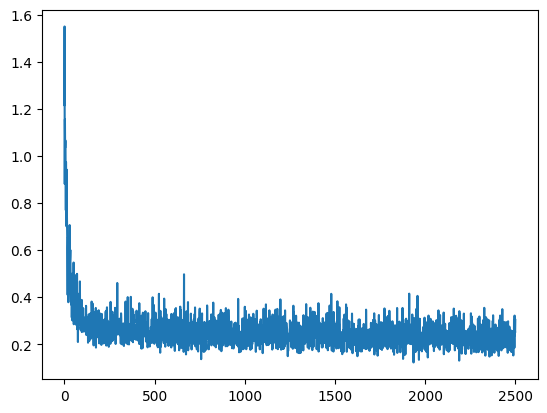

In [244]:
plt.plot(train_loss_arr)

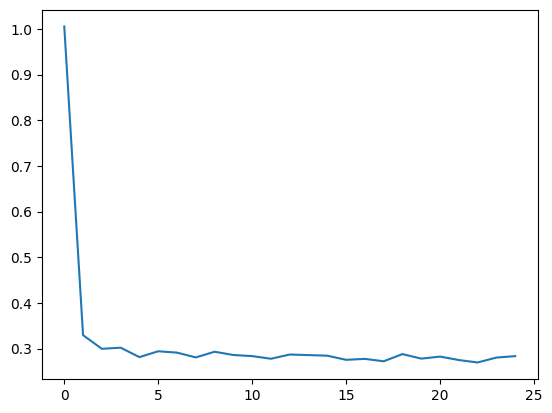

In [245]:
plt.plot(test_loss_arr)

# Fine Tuning

In [246]:
def calc_IOB_no_leak(inp_df, bolus, peak, dia):
  #Same as calc_IOB, but excludes the bolus AT the current timestep itself to prevent leak
  inp_df["running_IOB"] = 0.0
  inp_df["self_reported_carbs"] = 0.0
  for row in inp_df.itertuples():
    curr_iob = 0
    for row_bolus in bolus.itertuples():
      t = row.minutes - row_bolus.running_minutes
      if t < 0:
        break
      if t == 0:
        continue
      if t < 5:
        inp_df.at[row.Index, "self_reported_carbs"] = row_bolus.bwz_carb_input
      if t <= peak:
        curr_iob += row_bolus.dose * (1 - ((t ** 2) / (dia * peak)))
      elif t <= dia:
        curr_iob += row_bolus.dose * iob_falling(t, peak, dia)
    inp_df.at[row.Index, "running_IOB"] = curr_iob
  return inp_df

In [247]:
def build_leak_free_x(subject_num, split, means, stds):
    df, bolus_df = load_data(subject_num, split)
    df = calc_IOB_no_leak(df, bolus_df, 75, 300)
    df = generate_cyclical_time_encoding(df)
    df["basis_gsr"] = np.log1p(df["basis_gsr"])
    df["self_reported_carbs"] = np.log1p(df["self_reported_carbs"])
    for col in signals[:-2]:
        df[col] = (df[col] - means[col]) / stds[col]
    df = df.fillna(0.0)
    return df, bolus_df

In [248]:
bolus_train = {}
bolus_test = {}
threshold = 4 # how many steps before the dose step should we define a valid bolus event

for subject in subject_ids + subject_ids_test:
  df, bolus_df = build_leak_free_x(subject, "training", means, stds)
  df = pd.merge_asof(
        df, bolus_df[["date_time", "dose"]],
        on='date_time',
        direction='backward',
        tolerance=pd.Timedelta('5min')
  )
  df['dose'] = df['dose'].notnull().astype(int)
  df['dose'] = df['dose'][::-1].rolling(window=threshold, min_periods=1).max()[::-1].fillna(0).astype(int)
  bolus_d = df["dose"].to_numpy().astype(np.float32)

  if subject in subject_ids:
    bolus_train[subject] = (df[signals], bolus_d)
  else:
    bolus_test[subject] = (df[signals], bolus_d)




In [249]:
def get_batch_bolus(batch_size, split):
    if split == "train": data_lib = bolus_train
    if split == "test": data_lib = bolus_test

    ids = torch.randint(len(data_lib), (batch_size,))
    key_list = list(data_lib.keys())
    ids = [(key_list[i],
            torch.randint(len(data_lib[key_list[i]][0]) - context_length, (1,)).item())
           for i in ids]

    bx = torch.stack([torch.from_numpy(data_lib[id][0][i:i+context_length]) for id, i in ids])
    by = torch.stack([torch.from_numpy(data_lib[id][1][i:i+context_length]) for id, i in ids])
    return bx, by

In [250]:
#creating pos_weight for use in the BCE loss
all_train_labels = np.concatenate([bolus_train[s][1] for s in subject_ids])

num_pos = all_train_labels.sum()
num_neg = len(all_train_labels) - num_pos

pos_weight = torch.tensor([num_neg / num_pos])
print(f"positive rate: {num_pos / len(all_train_labels):.4f}, pos_weight: {pos_weight.item():.2f}")

positive rate: 0.0635, pos_weight: 14.76


In [251]:
#load a fresh model and copy over weights from previous model
finetune_model = DecoderTransformer(d_model=d_model, nhead=attention_heads_per_block, num_layers=num_blocks)
finetune_model.load_state_dict(model.state_dict(), strict=False)

#makes sure previously trained params are not tampered
for param in finetune_model.parameters():
    param.requires_grad = False

for param in finetune_model.bolus_head.parameters():
    param.requires_grad = True

optimizer_frozen = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, finetune_model.parameters()),
    lr=1e-3
)